In [48]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [49]:
import torch
from matplotlib import pyplot as plt
import math
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [50]:
import pickle

data_name = "alpaca"
with open(f"activations_save/activations_llama_alpaca_rank.pkl", "rb") as f:
    activations = pickle.load(f)

In [51]:
import math
import numpy as np

def cache_all_layer_singular_values(layer_name, io_key="input", sample_idx=0):
    sv_dict = {}
    for layer in activations:
        if layer_name not in layer:
            continue
        layer_id = int(layer.split(".")[0].split("_")[1])
        x = activations[layer][io_key][sample_idx]
        X = x.reshape(-1, x.shape[-1]).to(torch.float32).to(device)
        sv = torch.linalg.svdvals(X).cpu()
        sv_dict[layer_id] = sv
    return sv_dict

def analyze_energy_ratio_from_sv_cache(sv_cache, rank_ratio):
    layer_ids, ratios, ks, totals = [], [], [], []
    for layer_id in sorted(sv_cache.keys()):
        sv = sv_cache[layer_id]
        k = max(1, int(math.ceil(len(sv) * rank_ratio)))
        energy = sv.pow(2)
        # energy = sv
        total = energy.sum()
        topk = energy[:k].sum()
        ratio = (topk / (total + 1e-12)).item()
        layer_ids.append(layer_id)
        ratios.append(ratio)
        ks.append(k)
        totals.append(total.item())
    return layer_ids, ratios, ks, totals

def plot_energy_ratios(layer_ids, ratios, layer_name, rank_ratio):
    plt.figure(figsize=(8, 4))
    plt.plot(layer_ids, ratios, marker="o")
    plt.xlabel("Layer id")
    plt.ylabel("Energy captured (sum sigma^2)")
    plt.title(f"{layer_name}: rank_ratio={rank_ratio} energy capture")
    plt.ylim(0, 1.0)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
def plot_multi_rank_energy_ratios(sv_cache, layer_name, rank_ratios, legend_loc="best"):
    plt.figure(figsize=(8, 5))
    for rr in rank_ratios:
        layer_ids, ratios, ks, totals = analyze_energy_ratio_from_sv_cache(sv_cache, rr)
        plt.plot(layer_ids, ratios, marker="o", label=f"rank_ratio={rr:.4f}")
    plt.xlabel("Layer id")
    plt.ylabel("Energy captured (sum sigma^2)")
    plt.title(f"{layer_name}: Energy ratio for different rank_ratio")
    plt.ylim(0, 1.0)
    plt.grid(True)
    plt.legend(loc=legend_loc)
    plt.tight_layout()
    plt.show()
    

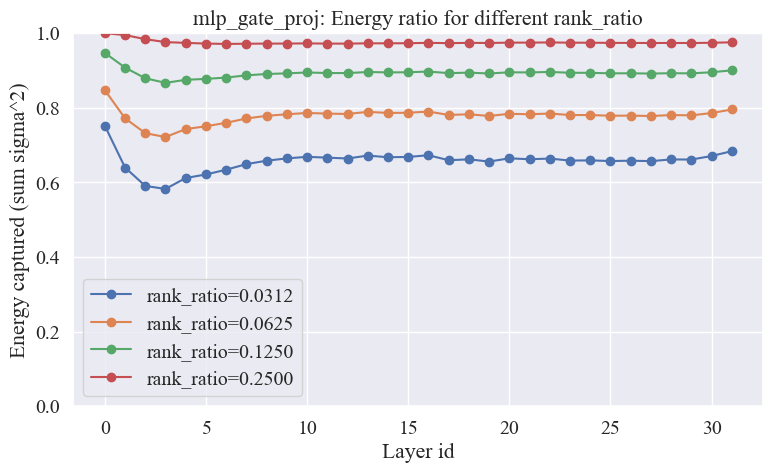

In [52]:
# 只需SVD一次，缓存所有层的奇异值
mlp_layer_name = "mlp_gate_proj"  # 例如："mlp_gate_proj"、"self_attn_o_proj"等
mlp_sv_cache = cache_all_layer_singular_values(mlp_layer_name, io_key="input", sample_idx=0)

# 示例用法
rank_ratios = [1/32, 1/16, 1/8, 1/4]
plot_multi_rank_energy_ratios(mlp_sv_cache, "mlp_gate_proj", rank_ratios)

In [53]:
import pickle

with open(f"activations_save/activations_vit_cifar100_rank.pkl", "rb") as f:
    activations = pickle.load(f)

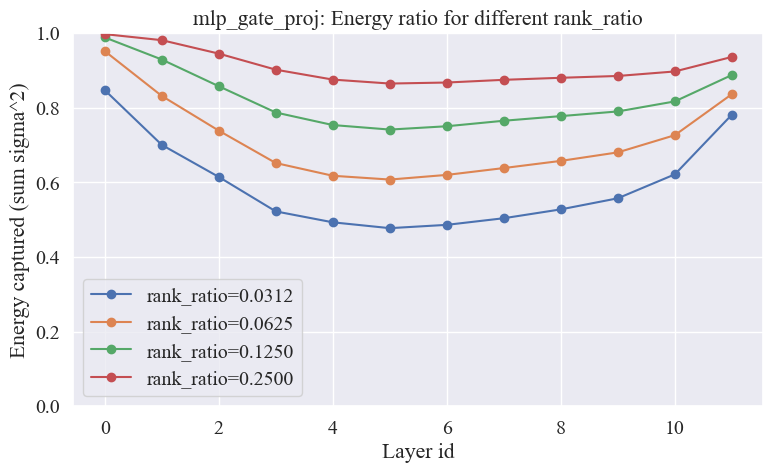

In [54]:
# 只需SVD一次，缓存所有层的奇异值
mlp_layer_name_vit = "mlp_gate_proj"  # 例如："mlp_gate_proj"、"self_attn_o_proj"等
mlp_sv_cache_vit = cache_all_layer_singular_values(mlp_layer_name_vit, io_key="input", sample_idx=0)

# 示例用法
rank_ratios = [1/32, 1/16, 1/8, 1/4]
plot_multi_rank_energy_ratios(mlp_sv_cache_vit, "mlp_gate_proj", rank_ratios)

<>:31: SyntaxWarning: invalid escape sequence '\s'
<>:31: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1692473/4276175046.py:31: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("Energy ratio (sum $\sigma^2$)", fontname="Times New Roman")


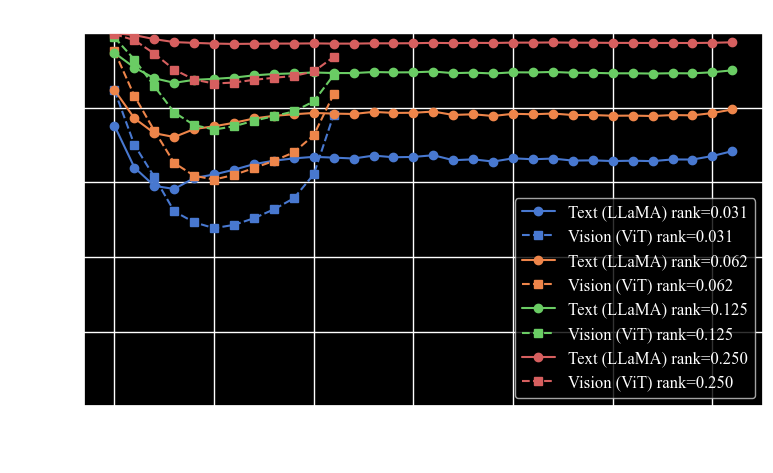

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_compare_energy_ratios(
    sv_cache1, sv_cache2, 
    layer_name, 
    rank_ratios, 
    label1="Text (LLaMA)", 
    label2="Vision (ViT)", 
    legend_loc="best"
):
    plt.figure(figsize=(8, 5))
    plt.style.use("dark_background")
    # sns.set_theme(font="Times New Roman", font_scale=1.3)
    # sns.set_theme(style="darkgrid", font="Times New Roman", font_scale=1.3)
    # sns.set_style("darkgrid")
    # "whitegrid"（论文常用，带网格线）
    # "darkgrid"
    # "white"
    # "dark"
    # "ticks"
    colors = sns.color_palette("muted", len(rank_ratios))
    for i, rr in enumerate(rank_ratios):
        # 文本任务
        layer_ids1, ratios1, _, _ = analyze_energy_ratio_from_sv_cache(sv_cache1, rr)
        plt.plot(layer_ids1, ratios1, marker="o", color=colors[i], label=f"{label1} rank={rr:.3f}")
        # 视觉任务
        layer_ids2, ratios2, _, _ = analyze_energy_ratio_from_sv_cache(sv_cache2, rr)
        plt.plot(layer_ids2, ratios2, marker="s", linestyle="--", color=colors[i], label=f"{label2} rank={rr:.3f}")
    plt.xlabel("Layer id", fontname="Times New Roman")
    plt.ylabel("Energy ratio (sum $\sigma^2$)", fontname="Times New Roman")
    plt.title(f"Energy ratio curves for {layer_name}", fontname="Times New Roman")
    plt.ylim(0, 1.0)
    plt.legend(loc=legend_loc, fontsize=12)
    plt.tight_layout()
    plt.show()

# 假设你已经有 mlp_sv_cache（文本）和 mlp_sv_cache_vit（视觉）
rank_ratios = [1/32, 1/16, 1/8, 1/4]
plot_compare_energy_ratios(
    mlp_sv_cache, mlp_sv_cache_vit, 
    "mlp_gate_proj", 
    rank_ratios, 
    label1="Text (LLaMA)", 
    label2="Vision (ViT)"
)

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

def collect_energy_ratio_data(sv_cache1, sv_cache2, rank_ratios):
    """
    返回结构:
    {
        'text': {rank_ratio1: (layer_ids, ratios), ...},
        'vision': {rank_ratio1: (layer_ids, ratios), ...}
    }
    """
    data = {'text': {}, 'vision': {}}
    for rr in rank_ratios:
        layer_ids1, ratios1, _, _ = analyze_energy_ratio_from_sv_cache(sv_cache1, rr)
        layer_ids2, ratios2, _, _ = analyze_energy_ratio_from_sv_cache(sv_cache2, rr)
        data['text'][rr] = (layer_ids1, ratios1)
        data['vision'][rr] = (layer_ids2, ratios2)
    return data

def plot_energy_ratio_curves(data, layer_name, rank_ratios, label1="Text (LLaMA)", label2="Vision (ViT)", legend_loc="best"):
    # plt.style.use("dark_background")
    sns.set(style="whitegrid", font="Times New Roman", font_scale=1.3)
    plt.figure(figsize=(8, 5))
    colors = sns.color_palette("tab10", len(rank_ratios))
    for i, rr in enumerate(rank_ratios):
        layer_ids1, ratios1 = data['text'][rr]
        layer_ids2, ratios2 = data['vision'][rr]
        plt.plot(layer_ids1, ratios1, marker="o", color=colors[i], label=f"{label1} rank={rr:.3f}")
        plt.plot(layer_ids2, ratios2, marker="s", linestyle="--", color=colors[i], label=f"{label2} rank={rr:.3f}")
    plt.xlabel("Layer id", fontname="Times New Roman")
    plt.ylabel(r"Energy ratio (sum $\sigma^2$)", fontname="Times New Roman")
    plt.title(f"Energy ratio curves for {layer_name}", fontname="Times New Roman")
    plt.ylim(0, 1.0)
    plt.legend(loc=legend_loc, fontsize=12)
    plt.tight_layout()
    plt.show()

# 用法示例
rank_ratios = [1/32, 1/16, 1/8, 1/4]
data = collect_energy_ratio_data(mlp_sv_cache, mlp_sv_cache_vit, rank_ratios)

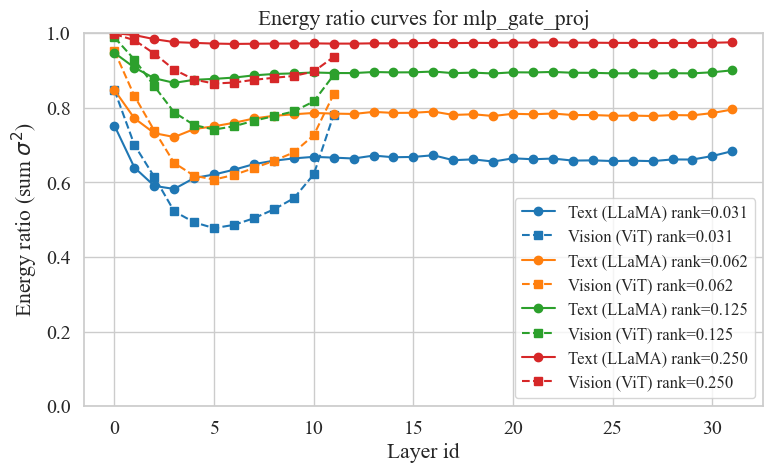

In [57]:
plot_energy_ratio_curves(data, "mlp_gate_proj", rank_ratios)

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_energy_ratio_curves_normed_x(
    data, layer_name, rank_ratios, 
    label1="Text (LLaMA)", label2="Vision (ViT)", legend_loc="best"
):
    plt.style.use("dark_background")
    sns.set(font="Times New Roman", font_scale=1.3)
    plt.figure(figsize=(8, 5))
    colors = sns.color_palette("tab10", len(rank_ratios))
    for i, rr in enumerate(rank_ratios):
        layer_ids1, ratios1 = data['text'][rr]
        layer_ids2, ratios2 = data['vision'][rr]
        x1 = np.linspace(0, 1, len(layer_ids1))
        x2 = np.linspace(0, 1, len(layer_ids2))
        plt.plot(x1, ratios1, marker="o", color=colors[i], label=f"{label1} rank={rr:.3f}")
        plt.plot(x2, ratios2, marker="s", linestyle="--", color=colors[i], label=f"{label2} rank={rr:.3f}")
    plt.xlabel("Normalized Layer Position", fontname="Times New Roman")
    plt.ylabel(r"Energy ratio (sum $\sigma^2$)", fontname="Times New Roman")
    plt.title(f"Energy ratio curves for {layer_name}", fontname="Times New Roman")
    plt.ylim(0, 1.0)
    plt.legend(loc=legend_loc, fontsize=12)
    plt.tight_layout()
    plt.show()

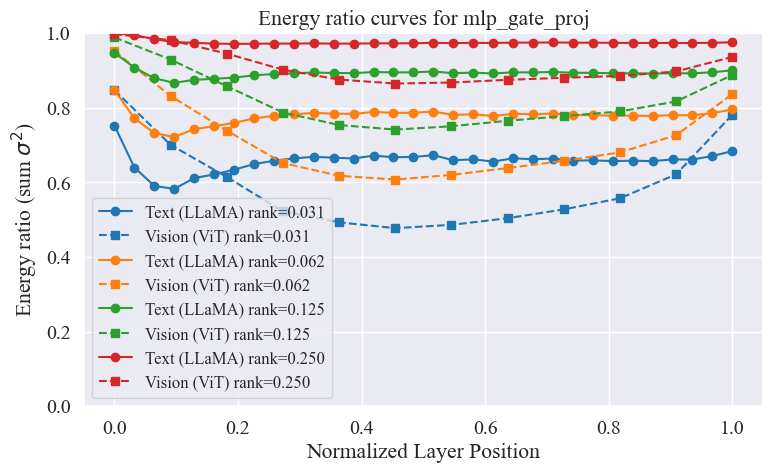

In [59]:
plot_energy_ratio_curves_normed_x(data, "mlp_gate_proj", rank_ratios)